In [52]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from tqdm import tqdm
from ipywidgets import interact, IntSlider
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit
import os


import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import os
import pickle
import json
#### PLOT THE DATA #######
# Generalized variables
textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/excitation_scan/'


In [53]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 


with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  
particle_ref=line.particle_ref

line.build_tracker()
#line.freeze_longitudinal()
# line.optimize_for_tracking()

twiss=line.twiss()

clight=constants.speed_of_light
circumference = line.get_length()


#%%
###################
# Linear Transfer #
###################

qx=twiss['qx']
qy=twiss['qy']
dqx=twiss['dqx']
dqy=twiss['dqy']
circumference=twiss['s'][-1]
# beta_x=twiss['betx'][-1]
# beta_y=twiss['bety'][-1]

qs=twiss['qs']
bets=twiss['bets0']
voltage_rf=7*1e6
frequency=201.8251348335775*1e6
lag_rf=180
momentum_compaction_factor=twiss['momentum_compaction_factor']
slip_factor=['slip_factor']

# qs=0.0131
# bets=0.063/2e-4

#at interaction points: #from https://anaconda.org/petrenko/li_like_ca_in_sps/notebook
beta_x  =  54.614389 # m
beta_y  =  44.332517 # m
alpha_x = -1.535235
alpha_y =  1.314101

Dx  =  2.444732 # m
Dpx =  0.097522


Dy  =  0.0 # m
Dpy =  0.0

#index of gamma factory along SPS line: 16675

arc = xt.LineSegmentMap(
        qx=qx, qy=qy,
        dqx=0, dqy=0,
        length=circumference,
        alfx=alpha_x,
        alfy=alpha_y,
        betx=beta_x,
        bety=beta_y,
        
        dx=Dx,
        dpx=Dpx,
        dy=Dy,
        dpy=Dpy,
        qs=qs,
        bets=bets,
        # voltage_rf=voltage_rf,
        # lag_rf=lag_rf,
        # frequency_rf=frequency,
        # momentum_compaction_factor=momentum_compaction_factor,
        # longitudinal_mode = 'nonlinear',

        )


Xcoll not installed


Loading line from dict:   0%|          | 0/38786 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [54]:
from ion_properties import lead,calcium,xenon,xenon2nd

In [ ]:
ions_list=lead,xenon,calcium

for ion in ions_list:# Ion properties:
        q0 = ion.q0
        mass0 = ion.mass0
        # print('mass0',mass0*1e-9)

        # gamma = 96.08563421444993
        # gamma =96.08823512129918
        gamma = ion.gamma_rel
        #gamma = 205.62
        
        beta= np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref

        nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z= ion.bunch_length

        # emittance=nemitt/(beta*gamma)

        num_particles=int(5e4)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()

        particles = xp.generate_matched_gaussian_bunch(
                num_particles=num_particles,
                total_intensity_particles=bunch_intensity,
                nemitt_x=nemitt, nemitt_y=nemitt, sigma_z=sigma_z,
                particle_ref=particle_ref,
                line=line_arc,
                #ngine="single-rf-harmonic",        
                )
        particles._init_random_number_generator()        
        particles0=particles.copy()

        # sigma_dp=2e-4  
        sigma_dp=np.std(particles.delta)
        print('sigma_dp',sigma_dp*1e4)
        sigma_dp=2e-4 
        ##################
        # Laser Cooler #
        ##################

        #laser-ion beam collision angle
        theta_l = 2.6*np.pi/180 # rad
        #theta_l = ion.theta_l
        nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

        # Ion excitation energy:
        ion_excited_lifetime=ion.excited_lifetime
        hw0 = ion.hw0 # eV
        hc=constants.hbar*clight/constants.e # eV*m (ħc)
        lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

        lambda_l = ion.lambda_l
        
        # Shift laser wavelength for fast longitudinal cooling:
        #lambda_l = lambda_l*(1+1*sigma_dp) # m

        laser_frequency = clight/lambda_l # Hz
        sigma_w = 2*np.pi*laser_frequency*sigma_dp
        #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

        sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
        #print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        #print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

        laser_waist_radius = 1.3e-3 #m
        laser_energy = 5e-3
        #laser_energy = ion.pulse_energy
        laser_x = 0.5033557046979871*1e-3

        GF_IP = xt.PulsedLaser(
                        laser_x=laser_x,
                        laser_y=0,
                        laser_z=0,
                        
                        laser_direction_nx = 0,
                        laser_direction_ny = ny,
                        laser_direction_nz = nz,
                        laser_energy         = laser_energy, # J
                        laser_duration_sigma = sigma_t, # sec
                        laser_wavelength = lambda_l, # m
                        laser_waist_radius = laser_waist_radius, # m
                        laser_waist_shift = 0, # m
                        ion_excitation_energy = hw0, # eV
                        ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                        )
        
        T_per_turn = circumference/(clight*beta)
                        
        # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
        max_time_s = T_per_turn
        int_time_s = T_per_turn
        num_turns = int(max_time_s/T_per_turn)        
        save_interval = int(int_time_s/T_per_turn)


        # create a monitor object, to reduce holded data
        monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                n_repetitions=int(num_turns/save_interval),
                                repetition_period=save_interval,
                                num_particles=num_particles)
                                
        line = xt.Line(
                elements=[arc,GF_IP,monitor])
        
        # line = xt.Line(
        #         elements=[monitor,arc])

        context = xo.ContextCpu(omp_num_threads=1)
        line.build_tracker(_context=context)


        ###############################################################################

        laser_energy_list = np.linspace(1*1e-3, 8e-3, 5)   # J
        sigma_t_list = np.linspace(0.2e-12, 10e-12, 6)  # seconds (0.2 ps to 10 ps)

        laser_energy_list = np.linspace(0, 100e-3, 5)   # J
        sigma_t_list = np.linspace(0.2e-12, 10e-12, 6)  # seconds (0.2 ps to 10 ps)]

        laser_energy_list = [1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3,8e-3,9e-3,10e-3,11e-3]
        sigma_t_list = [1e-12,2e-12,3e-12,4e-12,5e-12,6e-12,7e-12,8e-12,9e-12,10e-12,]

        laser_energy_list = np.linspace(0, 2*laser_energy, 100)   # J
        sigma_t_list = np.linspace(0, 5e-12, 100)  # seconds (0.2 ps to 10 ps)]

        fraction_excited_array = np.zeros((len(sigma_t_list), len(laser_energy_list)))

        for i, sigma_t_loop in tqdm(enumerate(sigma_t_list)):
                for j, laser_energy_loop in enumerate(laser_energy_list):

                        particles=particles0.copy()
                        particles._init_random_number_generator()  

                        GF_IP.laser_energy=laser_energy_loop                      
                        GF_IP.laser_duration_sigma=sigma_t_loop   
                        

                        line.track(particles, num_turns=num_turns,
                                turn_by_turn_monitor=False,with_progress=False)

                        # extract relevant values
                        x = monitor.x[:,0]
                        px = monitor.px[:,0]
                        y = monitor.y[:,0]
                        py = monitor.py[:,0]
                        delta = monitor.delta[:,0]
                        zeta = monitor.zeta[:,0]
                        state = monitor.state[:,0]
                        time = monitor.at_turn[:, 0] * T_per_turn

                        gamma_x=(1+alpha_x**2)/beta_x
                        gamma_y=(1+alpha_y**2)/beta_y

                        action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
                        action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

                        emittance_x_twiss=np.mean(action_x)**beta*gamma/2
                        rms_dp_p=np.std(delta)
                        
                        excited=state==2

                        fraction_excitation = sum(excited)/len(excited)*100
                        
                        fraction_excited_array[i, j] = fraction_excitation


        np.savez(f'results/excitation/{ion.name}.npz',
         fraction_excited_array=fraction_excited_array,
         laser_energy_list=laser_energy_list,
         sigma_t_list=sigma_t_list)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
sigma_dp 2.0043884934161538
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


100it [03:12,  1.92s/it]

Compiling ContextCpu kernels...


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
sigma_dp 2.6108130025980762
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


100it [03:21,  2.02s/it]


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
sigma_dp 3.0233456861380867
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


100it [03:33,  2.13s/it]


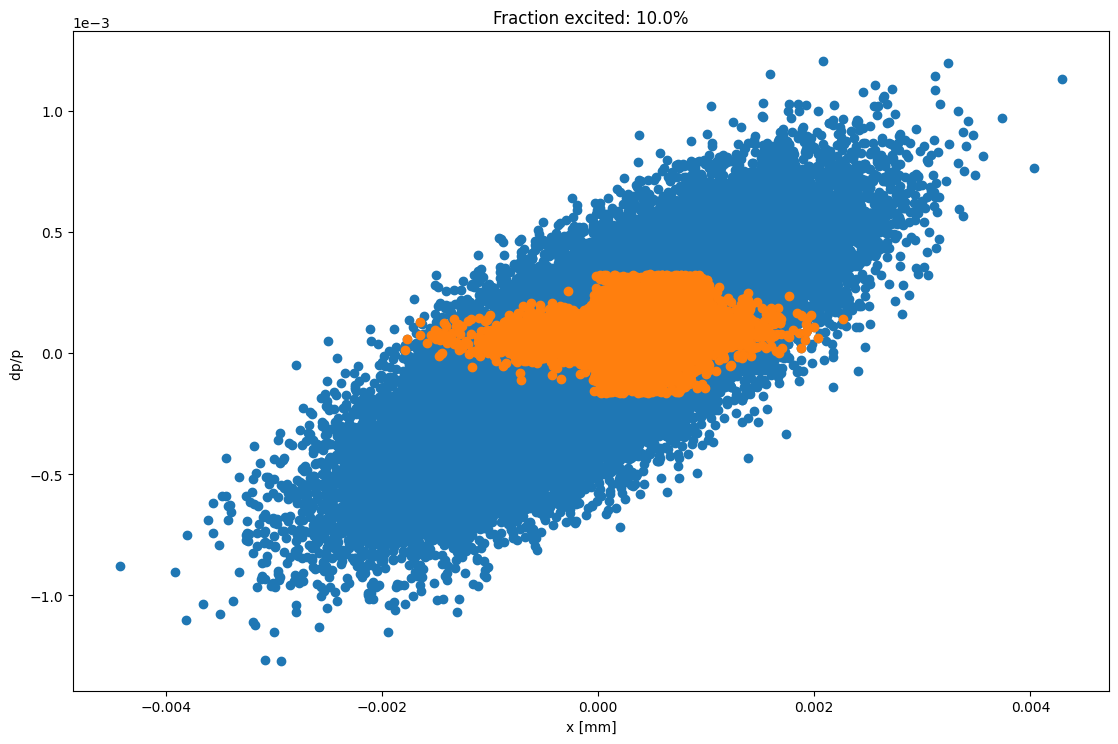

In [56]:
turn=1

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.title(f'Fraction excited: {round(fraction_excitation, 1)}%')

#plt.axvline(laser_x,color='red')
# plt.axvline(laser_x+laser_waist_radius,color='red')
# plt.axvline(laser_x-laser_waist_radius,color='red')

plt.scatter(x,delta)
plt.scatter(x[excited],delta[excited])
plt.xlabel('x [mm]')
plt.ylabel('dp/p ')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
#plt.savefig('First_turn.eps', format='eps', dpi=300)
plt.show()



In [57]:
# import numpy as np

# # Load the file
data = np.load(f'results/excitation/{ion.name}.npz')

# Check the content of the file
fraction_excited_array = data['fraction_excited_array']
laser_energy_list = data['laser_energy_list']
sigma_t_list = data['sigma_t_list']
# (Optional) print or use


# plt.figure()
# for i, energy in enumerate(laser_energy_list):
#     plt.plot(sigma_t_list, fraction_excited_array[:, i], label=f'{energy*1e3} mJ laser energy')

# plt.xlabel('Laser pulse duration [ps]')
# plt.ylabel('Fraction excited ions [%]')
# plt.title('Fraction of excited ions vs. Laser pulse duration')
# plt.legend()
# plt.grid(True)


<Figure size 590.551x364.961 with 0 Axes>

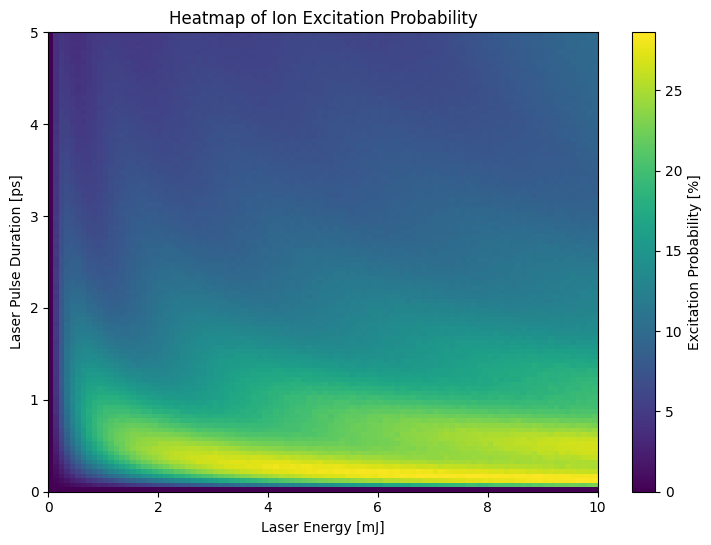

In [58]:
# Plotting the fraction of excited ions as a heatmap

plt.figure()


fraction_excited_array = data['fraction_excited_array']
laser_energy_list = data['laser_energy_list']  # in Joules
sigma_t_list = data['sigma_t_list']            # in seconds

# Convert laser energies to mJ (1 J = 1000 mJ) and pulse durations to ps (1 s = 1e12 ps)
laser_energy_mJ = np.array(laser_energy_list) * 1e3
sigma_t_ps = np.array(sigma_t_list) * 1e12

# Create the heatmap plot.
plt.figure(figsize=(8, 6))

# For imshow, set extent to map array indices to your physical values.
extent = [laser_energy_mJ[0], laser_energy_mJ[-1], sigma_t_ps[0], sigma_t_ps[-1]]

# Plot using imshow. origin='lower' ensures the lowest values appear at the bottom.
img = plt.imshow(fraction_excited_array, origin='lower', extent=extent, aspect='auto', cmap='viridis')
plt.colorbar(img, label='Excitation Probability [%]')
plt.xlabel('Laser Energy [mJ]')
plt.ylabel('Laser Pulse Duration [ps]')
plt.title('Heatmap of Ion Excitation Probability')
plt.tight_layout()
plt.show()



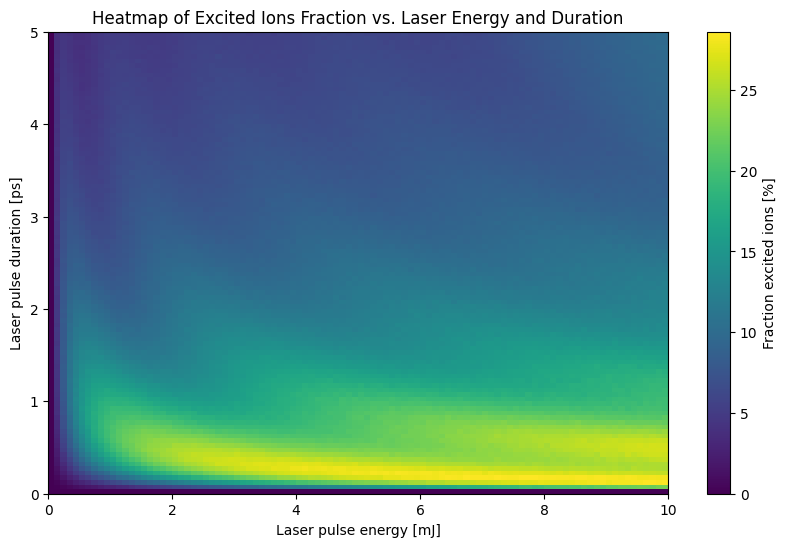

In [59]:
plt.figure(figsize=(10,6))

# Create the heatmap with the adjusted axes
plt.imshow(fraction_excited_array, aspect='auto', cmap='viridis', origin='lower',
           extent=[laser_energy_list[0] * 1e3, laser_energy_list[-1] * 1e3, sigma_t_list[0] * 1e12, sigma_t_list[-1] * 1e12])

# Add colorbar for better interpretation
plt.colorbar(label='Fraction excited ions [%]')

# Add labels and title
plt.xlabel('Laser pulse energy [mJ]')
plt.ylabel('Laser pulse duration [ps]')
plt.title('Heatmap of Excited Ions Fraction vs. Laser Energy and Duration')

plt.grid(False)
plt.show()